
# 연구 한눈에 보기

결과 파일(`artifacts/results`)을 읽어서 그림으로 보여주는 노트북이다. 학습은 하지 않는다. 실험이 진행 중이어도 언제든 **Kernel → Restart & Run All**로 다시 그리면 그때까지 나온 결과가 반영된다.

**핵심 원리**: 구조는 *틀*만 주고, 내용은 데이터에서 배우게 한다. 능력마다 전문 부품을 키우고, 능력이 여러 개 필요할 때 부품을 얼린 채 연결만 배워서 조합한다.

1–6절은 기초 실험(규칙 세계 v1/v2), 7절은 성장 사다리 1–5단계, 8절은 결론이다. 단계별 자세한 그림은 노트북 06–10에 있다.

| 색 | 뜻 |
|---|---|
| 파랑 | 우리가 밀고 있는 구조 (역할별 부품, 대칭 구조) |
| 주황 | 비교 대상: LLM 혼자, 또는 불안정했던 방법 |
| 청록 | 이상적인 기준 또는 중간 단계 |
| 회색 | 그 밖의 기준선 |


In [1]:

import matplotlib.pyplot as plt
from cognitive_lab import summary as S
from cognitive_lab import viz as V

V.setup()



## 1. 언어 모델은 읽기만, 판단은 따로 (규칙 세계 v1, seed 42)

점수: 맞히면 +1, `모름`이면 0, 틀리면 −1의 평균. 1이 만점이다.


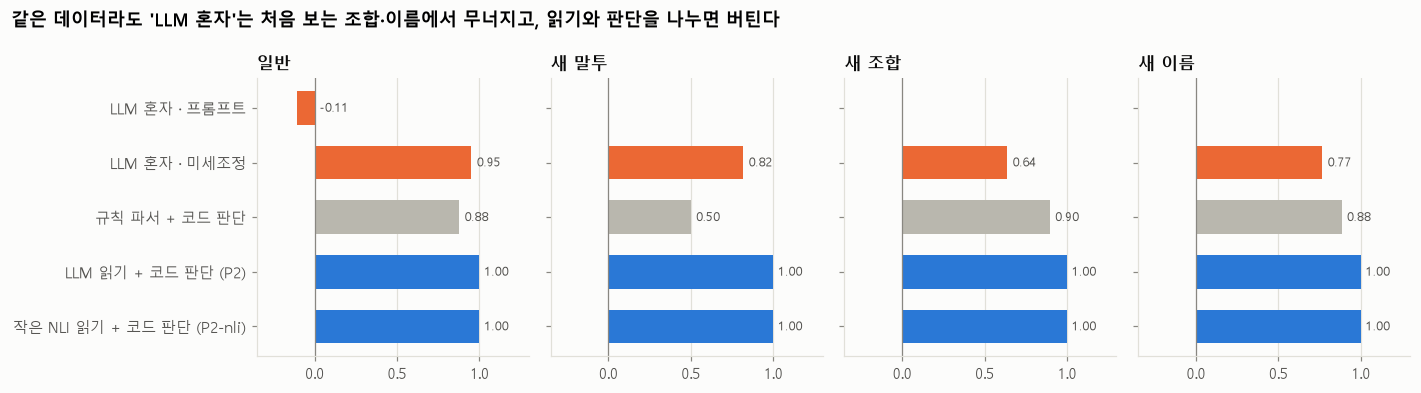

In [2]:

rows = S.v1_scores()
systems = [label for label, _, _ in S.V1_SYSTEMS]
role_color = {"parts": V.BLUE, "llm": V.ORANGE, "rule": V.NEUTRAL}
role_of = {label: role for label, _, role in S.V1_SYSTEMS}

fig, axes = plt.subplots(1, 4, figsize=(13, 3.6), sharey=True)
for ax, (_, split_label) in zip(axes, S.V1_SPLITS):
    for i, system in enumerate(systems):
        score = next((r["score"] for r in rows if r["system"] == system and r["split"] == split_label), None)
        if score is None:
            continue
        ax.barh(i, score, height=0.62, color=role_color[role_of[system]])
        ax.text(max(score, 0) + 0.03, i, f"{score:.2f}", va="center", fontsize=8.5, color=V.TEXT_SECONDARY)
    ax.axvline(0, color=V.MUTED, linewidth=0.8)
    ax.set_xlim(-0.35, 1.3)
    ax.set_title(split_label, fontsize=11)
    ax.grid(axis="y", visible=False)
axes[0].set_yticks(range(len(systems)), systems)
axes[0].invert_yaxis()
fig.suptitle("같은 데이터라도 'LLM 혼자'는 처음 보는 조합·이름에서 무너지고, 읽기와 판단을 나누면 버틴다",
             x=0.01, ha="left", fontsize=12, fontweight="bold")
fig.tight_layout()
plt.show()



## 2. 누구를 믿을지 경험으로 배우기 (규칙 세계 v2, 세션 100개 × seed 6개)

세션 하나는 문제 40개다. 문제마다 정답을 알려 주므로, 뒤로 갈수록 누가 믿을 만한지 알게 된다.


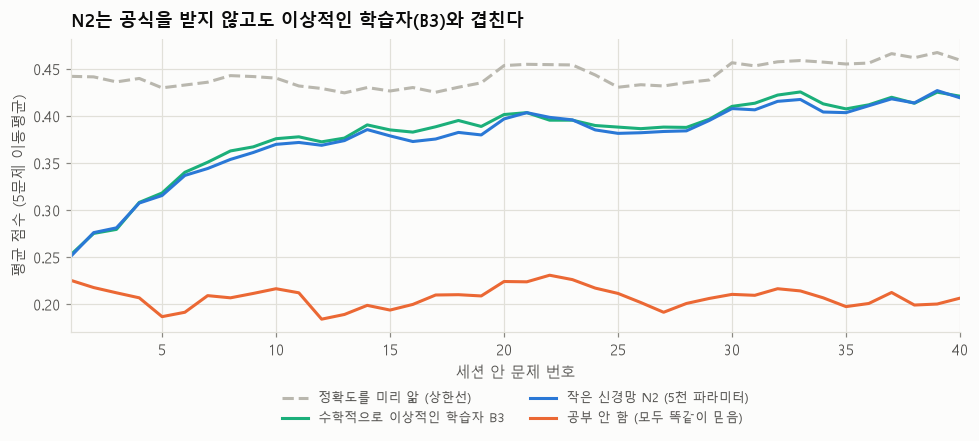

In [3]:

curves = S.v2_learning_curves(["o2", "b3-bayes-h01", "n2", "b1-equal"])
style = {
    "o2": ("정확도를 미리 앎 (상한선)", V.NEUTRAL, "--"),
    "b3-bayes-h01": ("수학적으로 이상적인 학습자 B3", V.AQUA, "-"),
    "n2": ("작은 신경망 N2 (5천 파라미터)", V.BLUE, "-"),
    "b1-equal": ("공부 안 함 (모두 똑같이 믿음)", V.ORANGE, "-"),
}
fig, ax = plt.subplots(figsize=(9, 4.2))
for agent, curve in curves.items():
    label, color, dash = style[agent]
    smooth = [sum(curve[max(0, i - 2): i + 3]) / len(curve[max(0, i - 2): i + 3]) for i in range(40)]
    ax.plot(range(1, 41), smooth, dash, color=color, label=label)
ax.set_xlim(1, 40)
ax.set_xlabel("세션 안 문제 번호")
ax.set_ylabel("평균 점수 (5문제 이동평균)")
ax.set_title("N2는 공식을 받지 않고도 이상적인 학습자(B3)와 겹친다", pad=8)
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.16), ncol=2, fontsize=8.5)
fig.tight_layout()
plt.show()



## 3. 세상이 수식대로 안 움직일 때 (오설정 세계 v2-M, seed 6개)

정확한 표준 계산(B4)과의 차이다. 점은 평균이고, 가로선은 95% 신뢰구간이다. 선이 0을 넘지 않고 오른쪽에 있으면 확실히 낫다는 뜻이다.


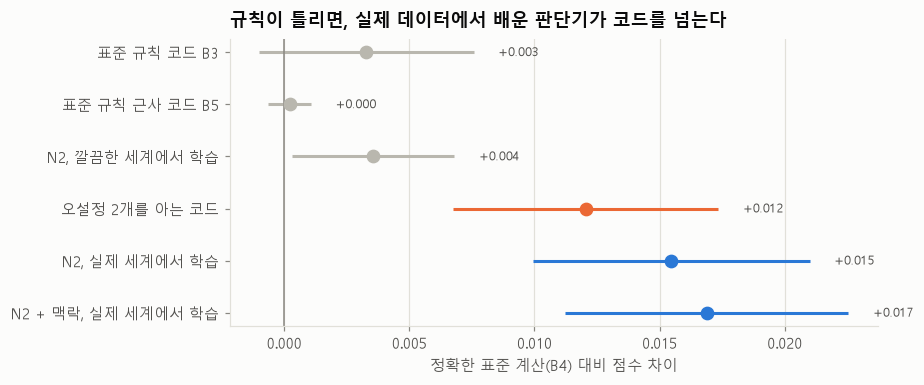

In [4]:

order = [
    ("b3-bayes-h01", "표준 규칙 코드 B3", V.NEUTRAL),
    ("b5-adf", "표준 규칙 근사 코드 B5", V.NEUTRAL),
    ("n2", "N2, 깔끔한 세계에서 학습", V.NEUTRAL),
    ("b3-informed-h02", "오설정 2개를 아는 코드", V.ORANGE),
    ("n2-mis", "N2, 실제 세계에서 학습", V.BLUE),
    ("n2-mis-ctx", "N2 + 맥락, 실제 세계에서 학습", V.BLUE),
]
rows = {r["agent"]: r for r in S.paired_vs([a for a, _, _ in order], "b4-joint", "_mis")}
fig, ax = plt.subplots(figsize=(8.5, 3.6))
for i, (agent, label, color) in enumerate(order):
    if agent not in rows:
        continue
    r = rows[agent]
    ax.errorbar(r["diff"], i, xerr=r["half"], fmt="o", color=color, markersize=8, capsize=0, elinewidth=2)
    ax.text(r["diff"] + r["half"] + 0.001, i, f"{r['diff']:+.3f}", va="center", fontsize=8.5, color=V.TEXT_SECONDARY)
ax.axvline(0, color=V.MUTED, linewidth=1)
ax.set_yticks(range(len(order)), [label for _, label, _ in order])
ax.invert_yaxis()
ax.grid(axis="y", visible=False)
ax.set_xlabel("정확한 표준 계산(B4) 대비 점수 차이")
ax.set_title("규칙이 틀리면, 실제 데이터에서 배운 판단기가 코드를 넘는다", pad=8)
fig.tight_layout()
plt.show()



## 4. 정보원이 많아질 때 계산 비용 (문제 하나당, seed 42)

정확한 계산은 사람 수 S에 대해 4^S로 커진다. 세로축은 로그 눈금이다.


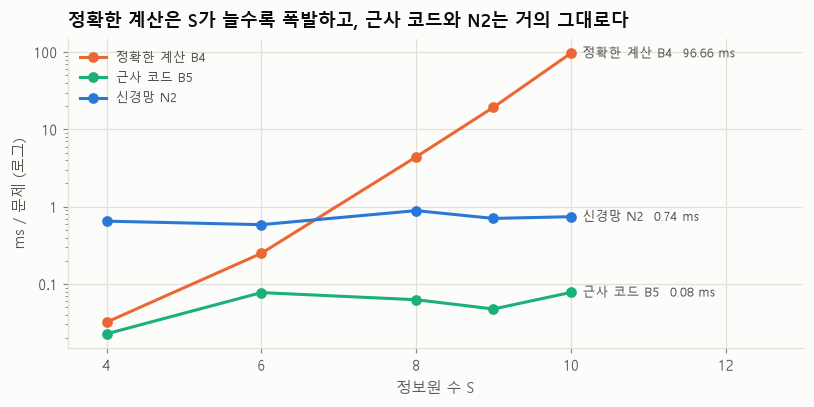

In [5]:

timing = S.scaling_timing()
lines = {"b4-exact": ("정확한 계산 B4", V.ORANGE), "b5-adf": ("근사 코드 B5", V.AQUA), "n2": ("신경망 N2", V.BLUE)}
fig, ax = plt.subplots(figsize=(7.5, 3.8))
for name, (label, color) in lines.items():
    points = sorted((s, ms) for s, n, ms in timing if n == name)
    if not points:
        continue
    xs, ys = zip(*points)
    ax.plot(xs, ys, "-o", color=color, markersize=6, label=label)
    ax.text(xs[-1] + 0.15, ys[-1], f"{label}  {ys[-1]:.2f} ms", va="center", fontsize=8.5, color=V.TEXT_SECONDARY)
ax.set_yscale("log")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda value, _: f"{value:g}"))
ax.set_xlim(3.5, 13)
ax.set_xlabel("정보원 수 S")
ax.set_ylabel("ms / 문제 (로그)")
ax.set_title("정확한 계산은 S가 늘수록 폭발하고, 근사 코드와 N2는 거의 그대로다", pad=8)
ax.legend(loc="upper left", fontsize=8.5)
fig.tight_layout()
plt.show()



## 5. 부품 사이의 형식과 판단기 구조 (규칙 세계 v1, 처음 보는 조합)

점 하나가 seed 하나, 세로 막대는 평균이다. 점이 넓게 퍼질수록 불안정하다는 뜻이다. 문장을 벡터 하나로 만드는 E2E는 모든 실행이 찍기 이하라서 그림에서 뺐다(설계 문서 참고).


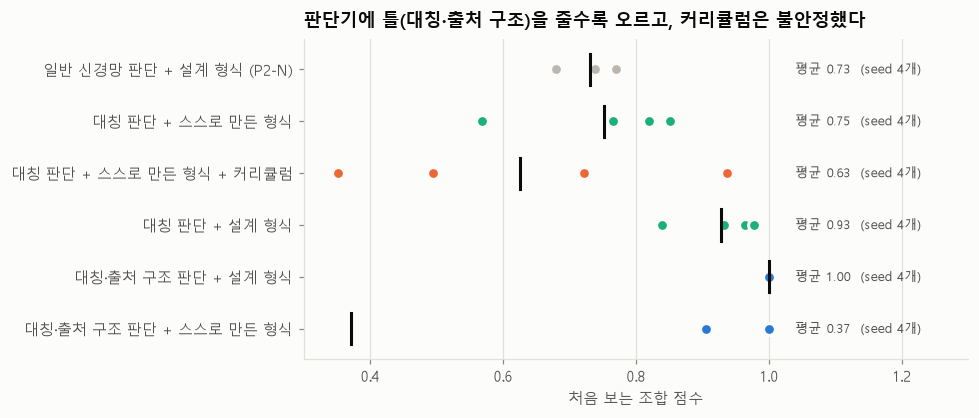

In [6]:

rows = S.interface_seeds()
role_color = {"flat": V.NEUTRAL, "learned": V.AQUA, "curriculum": V.ORANGE, "designed": V.AQUA,
              "sourcefold": V.BLUE, "sourcefold-learned": V.BLUE}
fig, ax = plt.subplots(figsize=(9, 3.9))
for i, row in enumerate(rows):
    scores = list(row["scores"].values())
    color = role_color[row["role"]]
    ax.scatter(scores, [i] * len(scores), s=60, color=color, edgecolor=V.SURFACE, linewidth=2, zorder=3)
    mean = sum(scores) / len(scores)
    ax.plot([mean, mean], [i - 0.3, i + 0.3], color=V.TEXT, linewidth=2, zorder=4)
    ax.text(1.04, i, f"평균 {mean:.2f}  (seed {len(scores)}개)", va="center", fontsize=8.5, color=V.TEXT_SECONDARY)
ax.set_yticks(range(len(rows)), [r["system"] for r in rows])
ax.invert_yaxis()
ax.set_xlim(0.3, 1.3)
ax.grid(axis="y", visible=False)
ax.set_xlabel("처음 보는 조합 점수")
ax.set_title("판단기에 틀(대칭·출처 구조)을 줄수록 오르고, 커리큘럼은 불안정했다", pad=8)
fig.tight_layout()
plt.show()



## 6. 스스로 만든 형식은 처음 보는 말투·이름에도 통하나 (seed 42)

정답 구조 없이 최종 답만으로 메시지를 학습한 시스템이다. 왼쪽은 시험 점수, 오른쪽은 메시지 안에 사람이 설계한 "뒷받침/반박/무관" 구분이 얼마나 담겼는지다(탐침 정확도, 찍기 기준 0.74).


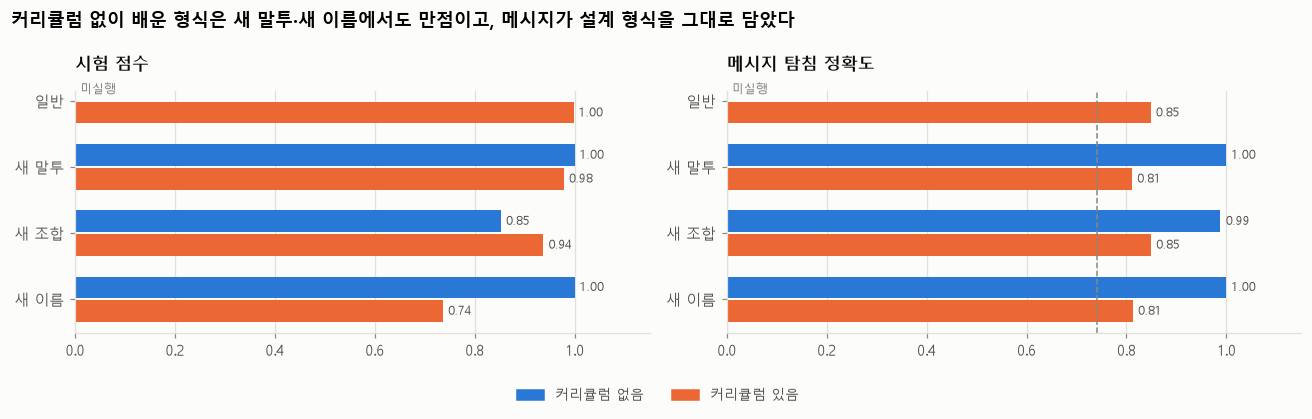

In [7]:

stems = [("interface-anchored-learned", "커리큘럼 없음", V.BLUE), ("interface-anchored-learned-curriculum", "커리큘럼 있음", V.ORANGE)]
rows = S.interface_splits([stem for stem, _, _ in stems])
splits = [label for _, label in S.V1_SPLITS]
fig, axes = plt.subplots(1, 2, figsize=(12, 3.6))
width = 0.36
for j, (stem, label, color) in enumerate(stems):
    for ax, field in zip(axes, ("score", "probe")):
        for i, split in enumerate(splits):
            value = next((r[field] for r in rows if r["stem"] == stem and r["split"] == split), None)
            y = i + (j - 0.5) * width
            if value is None:
                ax.text(0.01, y, "미실행", va="center", fontsize=8, color=V.MUTED)
                continue
            ax.barh(y, value, height=width * 0.9, color=color)
            ax.text(value + 0.01, y, f"{value:.2f}", va="center", fontsize=8, color=V.TEXT_SECONDARY)
for ax, title in zip(axes, ("시험 점수", "메시지 탐침 정확도")):
    ax.set_yticks(range(len(splits)), splits)
    ax.invert_yaxis()
    ax.set_xlim(0, 1.15)
    ax.grid(axis="y", visible=False)
    ax.set_title(title, fontsize=11, pad=14)
axes[1].axvline(0.742, color=V.MUTED, linewidth=1, linestyle="--")
from matplotlib.patches import Patch
fig.legend(handles=[Patch(color=color, label=label) for _, label, color in stems],
           loc="lower center", ncol=2, fontsize=9, bbox_to_anchor=(0.5, -0.04))
fig.suptitle("커리큘럼 없이 배운 형식은 새 말투·새 이름에서도 만점이고, 메시지가 설계 형식을 그대로 담았다",
             x=0.01, ha="left", fontsize=12, fontweight="bold")
fig.tight_layout(rect=(0, 0.06, 1, 1))
plt.show()



## 7. 성장 사다리 1–5단계 한눈에 보기

모든 단계에서 판정 기준을 결과 보기 전에 설계 문서(`design/`)에 적었다. 막대는 seed 3개 평균이고, 점은 seed 하나다. 그림은 1–5단계이고, 6–8단계 그림은 노트북 11–13에 있다.

| 단계 | 할 수 있게 된 것 | 새로 붙인 부품 | 결과 |
|---|---|---|---|
| 1. 듣고 믿을 사람 고르기 | 말투 속 신뢰 단서를 스스로 꺼내 씀 | 연결 머리 (6천) | 졸업 |
| 2. 스스로 공부하기 | 언제, 누구에게 물을지 정함 | 호기심 머리 (1만) | 졸업 |
| 3. 생각하기 | 3칸만 배우고 6칸 고리를 더 오래 생각해서 풂 | 생각 루프 + 멈춤 규칙 | 졸업 |
| 4. 쌓으며 크기 | 1·3단계 부품을 얼린 채 연결해서 새 문제를 풂 | 연결 장치 (184) | 졸업 |
| 5. 진짜 한국어 글 | 전문가(2.8억)가 범용 모델(12억)을 크게 이김. 판단 부품의 추가 기여는 없음 | 읽기 전문가 | 절반 통과 |
| 6. 진짜 글 + 조합 | 오보가 섞인 실제 기사에서 읽기 전문가 + 학습형 신뢰로 누가 거짓말하는지 배움 | 실제 글 신뢰 부품 (2,386) | 졸업 (노트북 11) |
| 7. 사령탑 | 무엇이 모자라는지 보고 부품을 스스로 부름. 처음 보는 조합(신뢰 → 생각)을 만들어 냄 | 사령탑 (1,249) | 졸업 (노트북 12) |
| 8. 스스로 성장 | 실패가 늘어날 때만 새 부품을 키움(새 말투엔 안 키우고, 새 관계 "다음 차례"에서 한 번) | "다음 차례" 가지 (6,170) | 졸업 (노트북 13) |


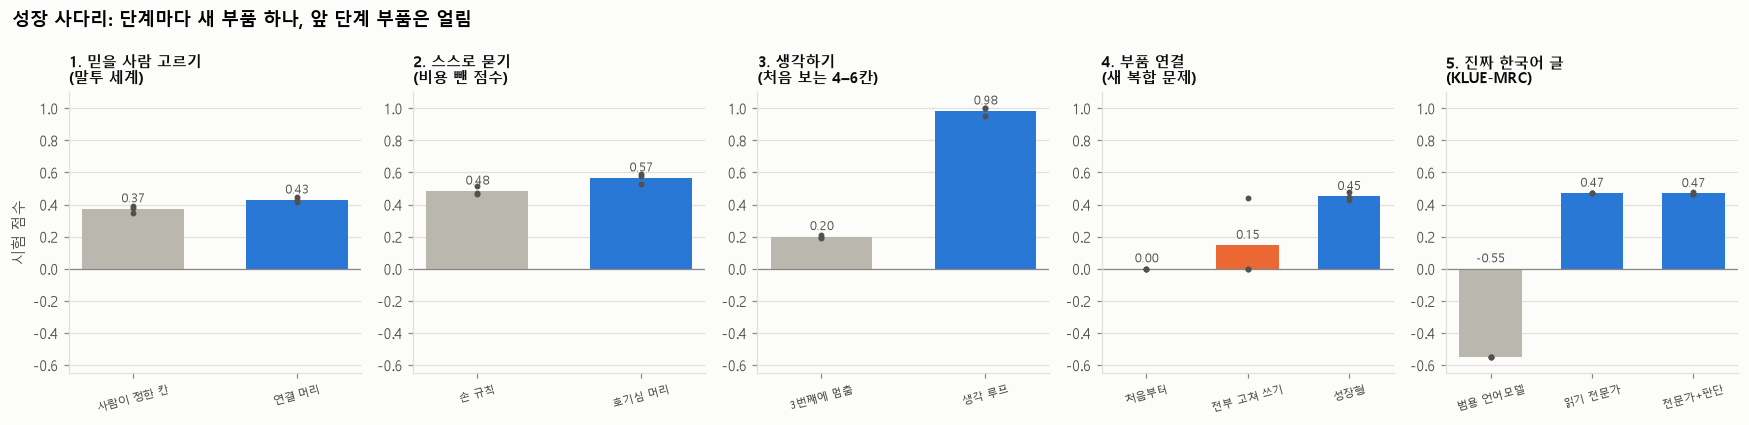

In [8]:

import json
import numpy as np

def load(name):
    return json.loads((S.RESULTS / name).read_text(encoding="utf-8"))

base = load("world-v2h_baselines.json")
def l46(r, forced):
    return np.mean([r["test"]["by_length"][str(l)]["forced"][2] if forced else r["test"]["by_length"][str(l)]["adaptive"]
                    for l in (4, 5, 6)])
A, B = (42, 43, 44), (45, 46, 47)
stages = [
    ("1. 믿을 사람 고르기\n(말투 세계)", [("사람이 정한 칸", [base[str(s)]["n2_designed_format"] for s in A]),
                                ("연결 머리", [load(f"world-v2h_connected-m8_seed-{s}.json")["test_score"] for s in A])]),
    ("2. 스스로 묻기\n(비용 뺀 점수)", [("손 규칙", [load(f"world-v2a_curiosity_cost-0.2_seed-{s}.json")["test"]["hand-rule"]["net"] for s in A]),
                               ("호기심 머리", [load(f"world-v2a_curiosity_cost-0.2_seed-{s}.json")["test"]["curiosity"]["net"] for s in A])]),
    ("3. 생각하기\n(처음 보는 4–6칸)", [("3번째에 멈춤", [l46(load(f"world-v3_thinker-grown_seed-{s}.json"), True) for s in B]),
                                ("생각 루프", [l46(load(f"world-v3_thinker-grown_seed-{s}.json"), False) for s in B])]),
    ("4. 부품 연결\n(새 복합 문제)", [("처음부터", [load(f"world-v4_scratch_seed-{s}.json")["test"]["score"] for s in A]),
                              ("전부 고쳐 쓰기", [load(f"world-v4_retune_seed-{s}.json")["test"]["score"] for s in A]),
                              ("성장형", [load(f"world-v4_grown_seed-{s}.json")["test"]["score"] for s in A])]),
    ("5. 진짜 한국어 글\n(KLUE-MRC)", [("범용 언어모델", [load(f"world-v5_mk1-reader_seed-{s}.json")["lm_alone"]["score"] for s in A]),
                                ("읽기 전문가", [load(f"world-v5_mk1-reader_seed-{s}.json")["reader_alone"]["score"] for s in A]),
                                ("전문가+판단", [load(f"world-v5_mk1-reader_seed-{s}.json")["mk1_v2"]["score"] for s in A])]),
]
highlight = {"연결 머리", "호기심 머리", "생각 루프", "성장형", "읽기 전문가", "전문가+판단"}
fig, axes = plt.subplots(1, 5, figsize=(16, 3.9))
for ax, (title, bars) in zip(axes, stages):
    for i, (label, values) in enumerate(bars):
        color = V.BLUE if label in highlight else (V.ORANGE if label == "전부 고쳐 쓰기" else V.NEUTRAL)
        m = float(np.mean(values))
        ax.bar(i, m, width=0.62, color=color)
        ax.scatter([i] * len(values), values, color=V.TEXT_SECONDARY, s=8, zorder=3)
        ax.text(i, max(m, 0) + 0.04, f"{m:.2f}", ha="center", fontsize=8, color=V.TEXT_SECONDARY)
    ax.axhline(0, color=V.MUTED, lw=0.8)
    ax.set_xticks(range(len(bars)), [b[0] for b in bars], fontsize=7.5, rotation=15)
    ax.set_ylim(-0.65, 1.1)
    ax.grid(axis="x", visible=False)
    ax.set_title(title, fontsize=9.5, pad=6)
axes[0].set_ylabel("시험 점수")
fig.suptitle("성장 사다리: 단계마다 새 부품 하나, 앞 단계 부품은 얼림", x=0.01, ha="left", fontsize=12, fontweight="bold")
fig.tight_layout()
plt.show()



## 8. 지금까지의 결론

**통한 원리**
1. **역할을 나누고, 틀은 주고 내용은 배우게 하라.** 대칭성과 출처 구조를 틀로 주면, 작은 신경망이 처음 보는 조합과 이름에서 버티고 최적 학습에 닿는다(1–6절).
2. **정보는 큰 부품 안에 이미 있다. 승부는 연결이 가른다.** 읽기 부품 안쪽에는 말투 정보가 100% 있었지만, 원래 연결(4칸 메시지)은 그것을 버렸다. 연결 머리를 배우자 회수됐다(사다리 1단계).
3. **결과만 보고도 메타 판단을 배운다.** 물어본 결과만으로 언제 모르는지, 누가 믿을 만한지 배웠다(2단계).
4. **가지치기와 순서대로 키우기.** 모든 연결을 켜고 가지치기하고, 연결을 먼저 배워 얼린 뒤 나머지를 배우자 처음 보는 긴 고리로 일반화했다. 언제 멈출지는 틀(고정점 규칙)로 줬다(3단계).
5. **얼리고 연결만 배워라. 연결은 "충실한 전달"로.** 부품 184개 연결로 새 문제를 풀었고 예전 능력도 그대로였다. 전부 고쳐 쓰면 망가졌다(4단계).
6. **능력마다 전문가를 키워라.** 진짜 한국어 글에서 2.8억 전문가가 12억 범용 모델을 크게 이겼다(5단계).
7. **조합은 진짜 글에서도 통한다.** 읽기 전문가는 오보를 못 알아채고, 신뢰 공식은 읽기 실수를 못 거른다. 둘을 함께 쓰는 학습형 조합이 둘 다 이겼다(6단계).
8. **"무엇이 모자라나"를 보고 불러라.** 겉모양이나 정체를 보는 사령탑은 혼동에 빠졌다. 모자란 것만 보는 사령탑은 학습 때 한 번도 안 해 본 부품 조합을 스스로 만들었다(7단계).
9. **처음 보는 것과 못 하는 것은 다르다. 실패를 보고 키워라.** 새로움에 반응하면 쓸데없이 키운다. "틀렸다"와 "모른다고 했는데 답이 있었다"를 실패로 세면, 필요한 순간에 딱 한 번 키운다(8단계).

**한계와 배운 것**
- 판단 부품은 읽기 부품이 가져온 것을 넘을 수 없다. 사슬은 가장 약한 고리만큼만 강하다(5단계 1차).
- 한 능력 안에서는 잘 키운 전문가 하나로 충분하다. 조합의 가치는 **여러 능력을 합쳐야 하는 문제**에서 나온다(5단계 2차).
- 확실한 사실만 보고 자란 부품은 불확실성을 나르지 못한다(4단계).
- 언제 멈출지를 학습으로 일반화하는 것은 아직 불안정하다(3단계).
- 철회하거나 정정한 것: 커리큘럼 효과, "같이 배우면 멈춘다", 세계 지름길로 무효 처리한 3단계 1차 시험.

세부 수치와 실패 기록은 `design/research-log-2026-10-06.md`와 단계별 설계 문서에 있다.
